In [10]:
!pip install vaderSentiment

In [11]:
import pandas as pd

reviews = {
    "Review": [
        "The product is excellent and I really love it.",
        "Amazing quality and very fast delivery.",
        "I am happy with this purchase.",
        "The product is okay, nothing special.",
        "It is an average product for the price.",
        "The quality is poor and I am disappointed.",
        "Very bad experience. The product stopped working.",
        "I hate this product and would not recommend it.",
        "Good product, but delivery was late.",
        "The quality is excellent but the packaging was bad."
    ]
}

df_reviews = pd.DataFrame(reviews)

df_reviews

,Review
0,The product is excellent and I really love it.
1,Amazing quality and very fast delivery.
2,I am happy with this purchase.
3,"The product is okay, nothing special."
4,It is an average product for the price.
5,The quality is poor and I am disappointed.
6,Very bad experience. The product stopped working.
7,I hate this product and would not recommend it.
8,"Good product, but delivery was late."
9,The quality is excellent but the packaging was...


In [12]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_reviews["Sentiment"] = df_reviews["Review"].apply(get_sentiment)

df_reviews

,Review,Sentiment
0,The product is excellent and I really love it.,Positive
1,Amazing quality and very fast delivery.,Positive
2,I am happy with this purchase.,Positive
3,"The product is okay, nothing special.",Negative
4,It is an average product for the price.,Neutral
5,The quality is poor and I am disappointed.,Negative
6,Very bad experience. The product stopped working.,Negative
7,I hate this product and would not recommend it.,Negative
8,"Good product, but delivery was late.",Positive
9,The quality is excellent but the packaging was...,Negative


In [13]:
sentiment_counts = df_reviews["Sentiment"].value_counts()

print("Sentiment Summary:")
print(sentiment_counts)

Sentiment Summary:
Sentiment
Negative    5
Positive    4
Neutral     1
Name: count, dtype: int64


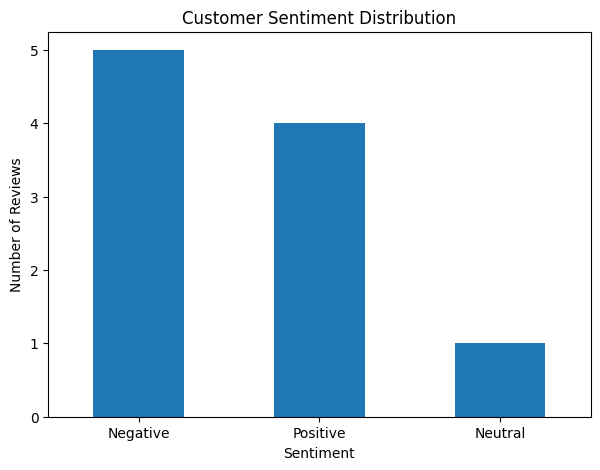

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [15]:
sentiment_percentage = (
    df_reviews["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("Sentiment Percentage:")
print(sentiment_percentage)

Sentiment Percentage:
Sentiment
Negative    50.0
Positive    40.0
Neutral     10.0
Name: proportion, dtype: float64


In [16]:
emotion_lexicon = {
    "Happy": ["happy", "amazing", "excellent", "good", "love"],
    "Angry": ["hate", "bad", "angry"],
    "Sad": ["disappointed", "poor"],
    "Neutral": ["okay", "average", "nothing"]
}

def detect_emotion(text):
    text = text.lower()

    scores = {}

    for emotion, words in emotion_lexicon.items():
        scores[emotion] = sum(word in text for word in words)

    if max(scores.values()) == 0:
        return "Neutral"

    return max(scores, key=scores.get)

df_reviews["Emotion"] = df_reviews["Review"].apply(detect_emotion)

df_reviews

,Review,Sentiment,Emotion
0,The product is excellent and I really love it.,Positive,Happy
1,Amazing quality and very fast delivery.,Positive,Happy
2,I am happy with this purchase.,Positive,Happy
3,"The product is okay, nothing special.",Negative,Neutral
4,It is an average product for the price.,Neutral,Neutral
5,The quality is poor and I am disappointed.,Negative,Sad
6,Very bad experience. The product stopped working.,Negative,Angry
7,I hate this product and would not recommend it.,Negative,Angry
8,"Good product, but delivery was late.",Positive,Happy
9,The quality is excellent but the packaging was...,Negative,Happy


In [17]:
emotion_counts = df_reviews["Emotion"].value_counts()

print("Emotion Summary:")
print(emotion_counts)

Emotion Summary:
Emotion
Happy      5
Neutral    2
Angry      2
Sad        1
Name: count, dtype: int64


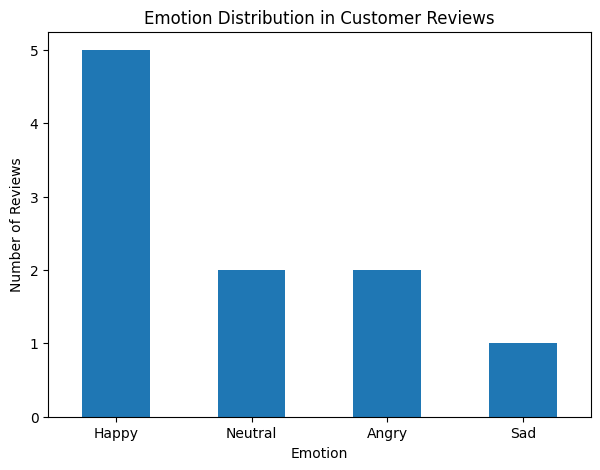

In [18]:
plt.figure(figsize=(7,5))

emotion_counts.plot(kind="bar")

plt.title("Emotion Distribution in Customer Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [19]:
print("FINAL SENTIMENT ANALYSIS")
print("------------------------")
print("Total reviews:", len(df_reviews))
print("Most common sentiment:", sentiment_counts.idxmax())
print("Most common emotion:", emotion_counts.idxmax())

print("\nKey Insights:")
print("1. Customer reviews contain positive, negative, and neutral opinions.")
print("2. Sentiment analysis helps identify the overall customer response.")
print("3. Emotion analysis helps understand specific feelings in reviews.")
print("4. These patterns can help businesses understand customer feedback.")

FINAL SENTIMENT ANALYSIS
------------------------
Total reviews: 10
Most common sentiment: Negative
Most common emotion: Happy

Key Insights:
1. Customer reviews contain positive, negative, and neutral opinions.
2. Sentiment analysis helps identify the overall customer response.
3. Emotion analysis helps understand specific feelings in reviews.
4. These patterns can help businesses understand customer feedback.
